   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Shape:
(150, 6)

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.

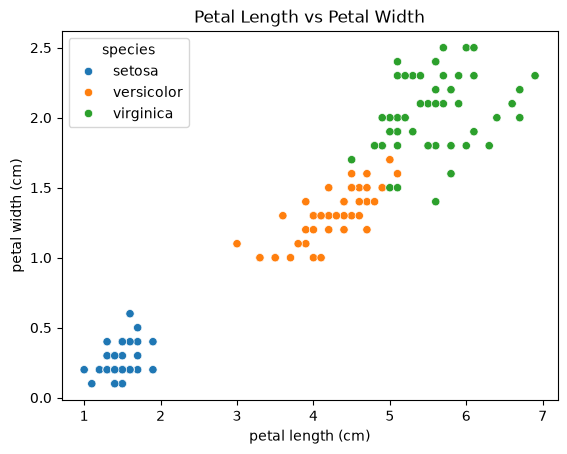


Training data: (120, 4)
Testing data: (30, 4)

Accuracy: 0.9333333333333333
Accuracy percentage: 93.33333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


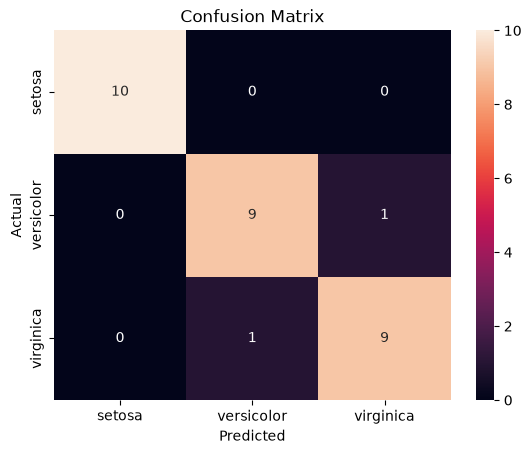


New Flower Prediction:
setosa


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print(df.head())

print("\nShape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["species"].value_counts())

print("\nStatistics:")
print(df.describe())

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)

plt.title("Petal Length vs Petal Width")
plt.show()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test,y_pred,target_names=iris.target_names))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

sns.heatmap(cm,annot=True,fmt="d",xticklabels=iris.target_names, yticklabels=iris.target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

new_flower = [[5.1, 3.5, 1.4, 0.2]]

new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)

print("\nNew Flower Prediction:")
print(iris.target_names[prediction[0]])